### ✅ Part 1: Data Loading + Data Understanding + Data Cleaning

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option("display.max_columns", None)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [74]:
# load dataset:
# Load dataset
df = pd.read_csv("data/car_price_prediction.csv")

# Display first 5 rows
df.head()

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4


In [3]:
print("Rows and Columns:")
print(df.shape)
df.sample(10)

Rows and Columns:
(19237, 18)


,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
12835,45797202,6272,-,OPEL,Astra,2000,Goods wagon,No,Diesel,2.0 Turbo,0 km,4.0,Manual,Front,04-May,Left wheel,Silver,2
13269,45809621,1254,831,HYUNDAI,Accent,2017,Sedan,Yes,Petrol,1.6,88771 km,4.0,Automatic,Front,04-May,Left wheel,Blue,12
498,45644667,18817,609,TOYOTA,Camry,2018,Sedan,Yes,Hybrid,2.5,35058 km,4.0,Automatic,Front,04-May,Left wheel,White,12
5596,45803052,42717,1017,HYUNDAI,Santa FE,2017,Jeep,Yes,Diesel,2,72040 km,4.0,Automatic,Front,04-May,Left wheel,Blue,4
11074,45661665,3763,1018,MERCEDES-BENZ,ML 350,2011,Jeep,Yes,Diesel,3,290501 km,6.0,Automatic,4x4,04-May,Left wheel,Black,12
17527,43485975,68681,-,TOYOTA,Tacoma TRD Off Road,2013,Pickup,No,LPG,4,71000 km,6.0,Automatic,4x4,04-May,Left wheel,Black,8
6003,45679578,10349,-,HONDA,Cr-v,2002,Jeep,Yes,Petrol,2,200000 km,4.0,Automatic,4x4,04-May,Right-hand drive,Carnelian red,4
3449,45807549,18817,753,KIA,Optima,2012,Sedan,Yes,Hybrid,2.4,119700 km,4.0,Tiptronic,Front,04-May,Left wheel,White,10
7822,45760368,2587,333,SUBARU,XV,2014,Jeep,Yes,Hybrid,2,123472 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
13382,45758148,470,289,FORD,Escape,2008,Jeep,Yes,Hybrid,0.4,115893 km,4.0,Automatic,Front,04-May,Left wheel,White,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19237 entries, 0 to 19236
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                19237 non-null  int64  
 1   Price             19237 non-null  int64  
 2   Levy              19237 non-null  str    
 3   Manufacturer      19237 non-null  str    
 4   Model             19237 non-null  str    
 5   Prod. year        19237 non-null  int64  
 6   Category          19237 non-null  str    
 7   Leather interior  19237 non-null  str    
 8   Fuel type         19237 non-null  str    
 9   Engine volume     19237 non-null  str    
 10  Mileage           19237 non-null  str    
 11  Cylinders         19237 non-null  float64
 12  Gear box type     19237 non-null  str    
 13  Drive wheels      19237 non-null  str    
 14  Doors             19237 non-null  str    
 15  Wheel             19237 non-null  str    
 16  Color             19237 non-null  str    
 17  Airb

In [5]:
df.describe(include="object")

,Levy,Manufacturer,Model,Category,Leather interior,Fuel type,Engine volume,Mileage,Gear box type,Drive wheels,Doors,Wheel,Color
count,19237,19237,19237,19237,19237,19237,19237,19237,19237,19237,19237,19237,19237
unique,559,65,1590,11,2,7,107,7687,4,3,3,2,16
top,-,HYUNDAI,Prius,Sedan,Yes,Petrol,2,0 km,Automatic,Front,04-May,Left wheel,Black
freq,5819,3769,1083,8736,13954,10150,3916,721,13514,12874,18332,17753,5033


In [6]:
print(df.columns)
df.dtypes

Index(['ID', 'Price', 'Levy', 'Manufacturer', 'Model', 'Prod. year',
       'Category', 'Leather interior', 'Fuel type', 'Engine volume', 'Mileage',
       'Cylinders', 'Gear box type', 'Drive wheels', 'Doors', 'Wheel', 'Color',
       'Airbags'],
      dtype='str')


ID                    int64
Price                 int64
Levy                    str
Manufacturer            str
Model                   str
Prod. year            int64
Category                str
Leather interior        str
Fuel type               str
Engine volume           str
Mileage                 str
Cylinders           float64
Gear box type           str
Drive wheels            str
Doors                   str
Wheel                   str
Color                   str
Airbags               int64
dtype: object

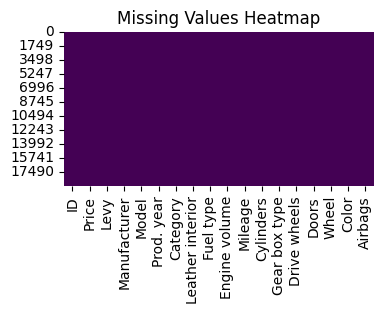

In [7]:
df.isnull().sum()
plt.figure(figsize=(4,2))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

In [8]:
missing = df.isnull().sum() / len(df) * 100
missing

ID                  0.0
Price               0.0
Levy                0.0
Manufacturer        0.0
Model               0.0
Prod. year          0.0
Category            0.0
Leather interior    0.0
Fuel type           0.0
Engine volume       0.0
Mileage             0.0
Cylinders           0.0
Gear box type       0.0
Drive wheels        0.0
Doors               0.0
Wheel               0.0
Color               0.0
Airbags             0.0
dtype: float64

In [9]:
print("Duplicate Rows:", df.duplicated().sum())
df.drop_duplicates(inplace=True)
df.shape

Duplicate Rows: 313


(18924, 18)

In [10]:
for col in df.columns:
    print(f"{col}: {df[col].nunique()}")

ID: 18924
Price: 2315
Levy: 559
Manufacturer: 65
Model: 1590
Prod. year: 54
Category: 11
Leather interior: 2
Fuel type: 7
Engine volume: 107
Mileage: 7687
Cylinders: 13
Gear box type: 4
Drive wheels: 3
Doors: 3
Wheel: 2
Color: 16
Airbags: 17


In [11]:
df.head()
df.info()

<class 'pandas.DataFrame'>
Index: 18924 entries, 0 to 19236
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                18924 non-null  int64  
 1   Price             18924 non-null  int64  
 2   Levy              18924 non-null  str    
 3   Manufacturer      18924 non-null  str    
 4   Model             18924 non-null  str    
 5   Prod. year        18924 non-null  int64  
 6   Category          18924 non-null  str    
 7   Leather interior  18924 non-null  str    
 8   Fuel type         18924 non-null  str    
 9   Engine volume     18924 non-null  str    
 10  Mileage           18924 non-null  str    
 11  Cylinders         18924 non-null  float64
 12  Gear box type     18924 non-null  str    
 13  Drive wheels      18924 non-null  str    
 14  Doors             18924 non-null  str    
 15  Wheel             18924 non-null  str    
 16  Color             18924 non-null  str    
 17  Airbags  

### 📒 Part 2 – Exploratory Data Analysis (EDA)

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

sns.set(font_scale=1)

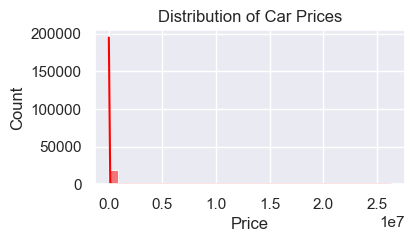

In [13]:
plt.figure(figsize=(4,2))
sns.histplot(df["Price"], bins=30, kde=True, color = 'red')
plt.title("Distribution of Car Prices")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

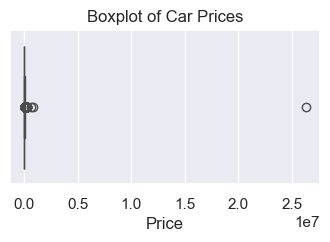

In [14]:
plt.figure(figsize=(4,2))
sns.boxplot(x=df["Price"])
plt.title("Boxplot of Car Prices")
plt.show()

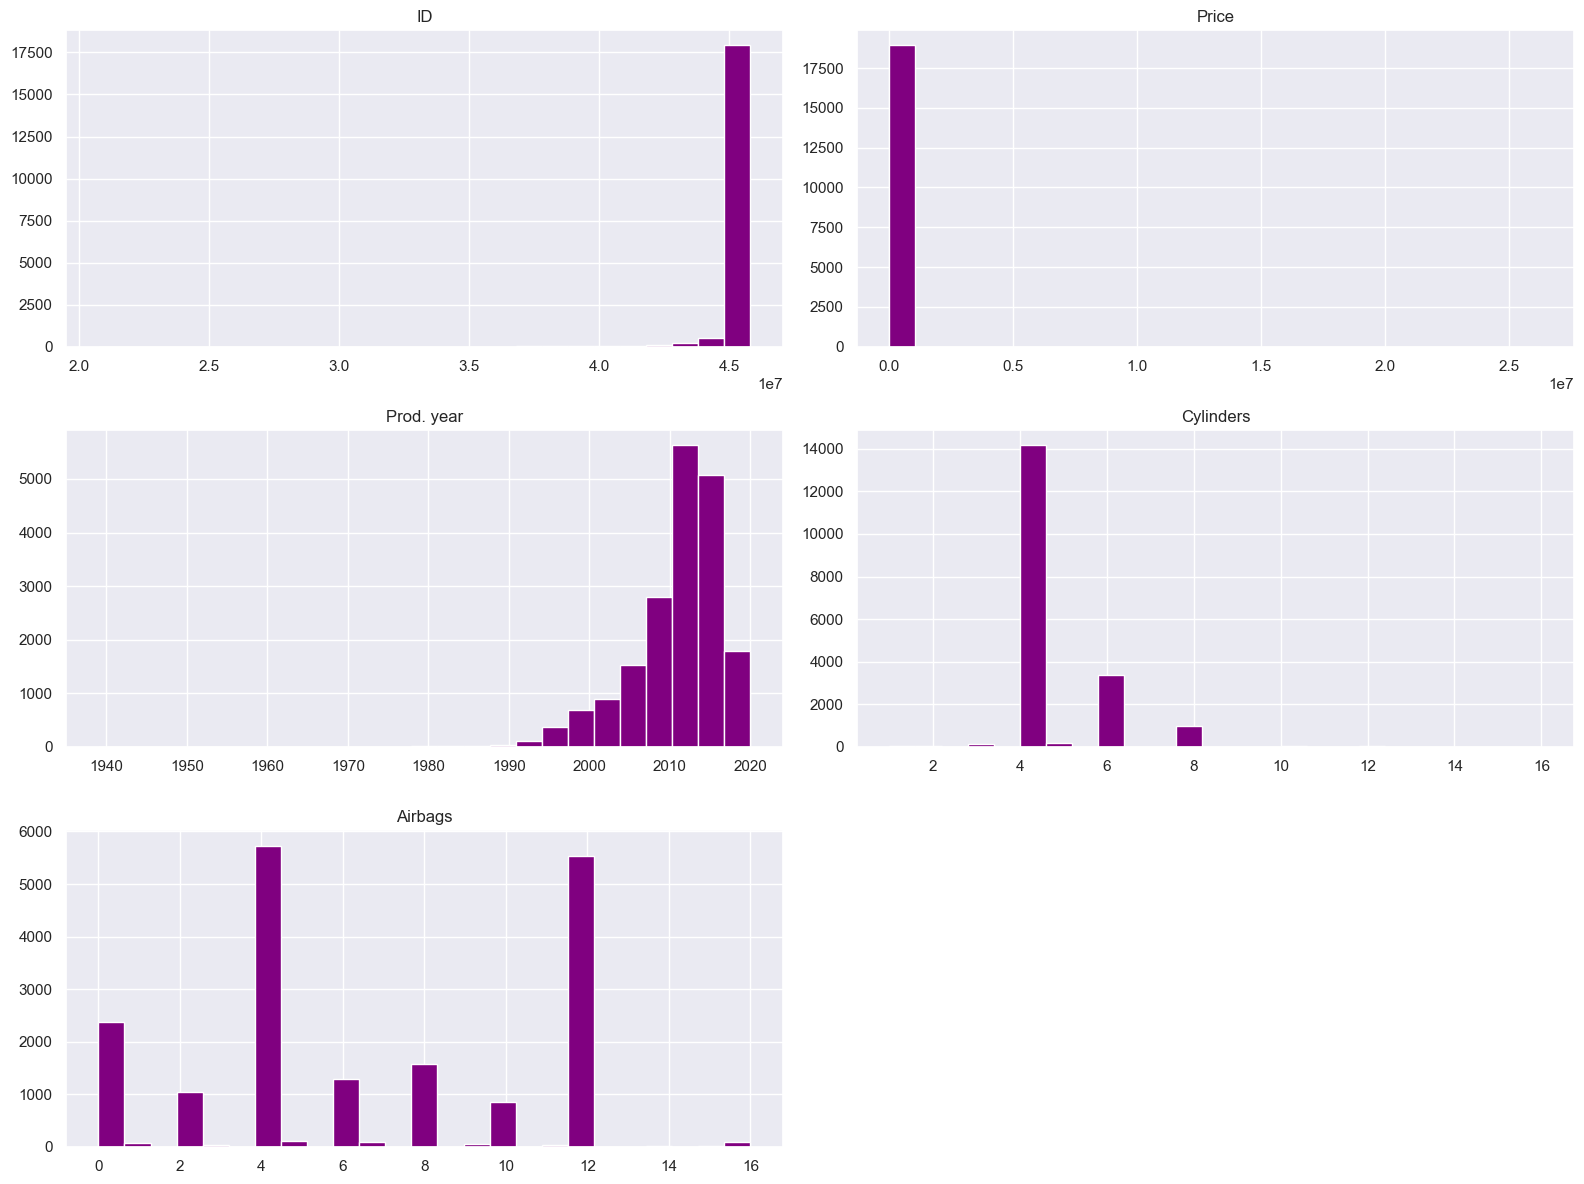

In [15]:
num_cols = df.select_dtypes(include="number").columns
df[num_cols].hist(figsize=(16,12), bins=25, color = 'purple')
plt.tight_layout()
plt.show()

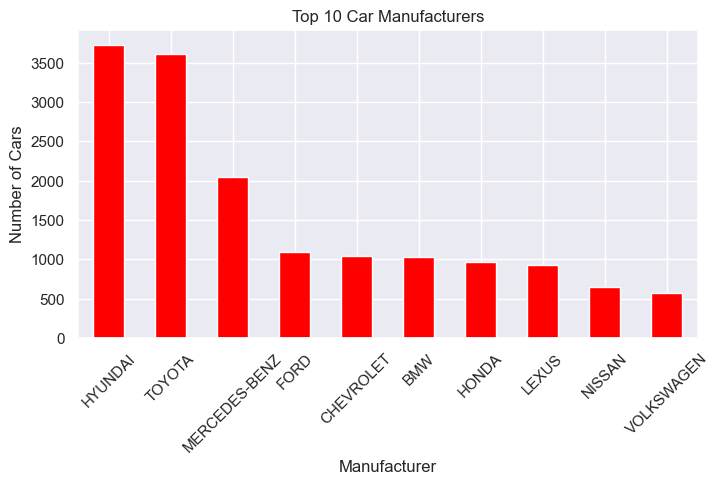

In [16]:
plt.figure(figsize=(8,4))
df["Manufacturer"].value_counts().head(10).plot(kind="bar", color ='red')
plt.title("Top 10 Car Manufacturers")
plt.xlabel("Manufacturer")
plt.ylabel("Number of Cars")
plt.xticks(rotation=45)

plt.show()

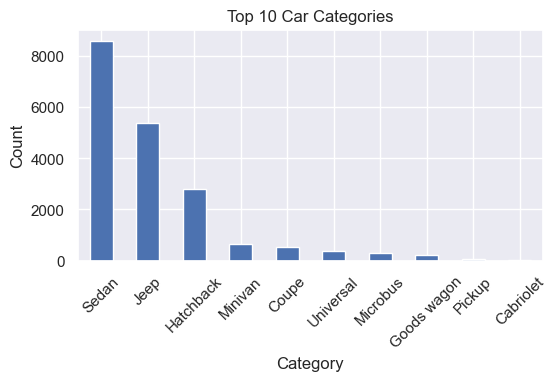

In [17]:
# top 10 categories:
plt.figure(figsize=(6,3))
df["Category"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Car Categories")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

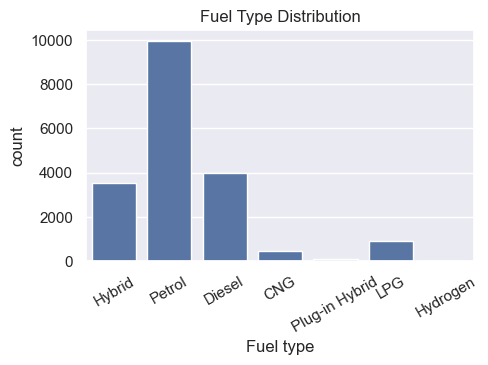

In [18]:
plt.figure(figsize=(5,3))
sns.countplot(data=df, x="Fuel type")
plt.title("Fuel Type Distribution")
plt.xticks(rotation=30)
plt.show()

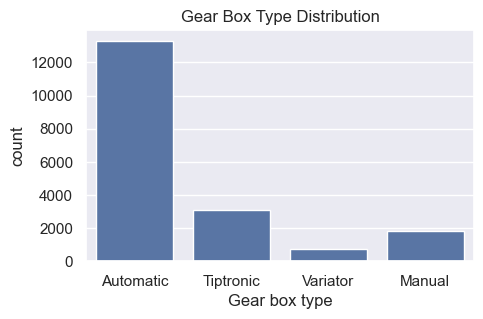

In [19]:
plt.figure(figsize=(5,3))
sns.countplot(data=df, x="Gear box type")
plt.title("Gear Box Type Distribution")
plt.show()

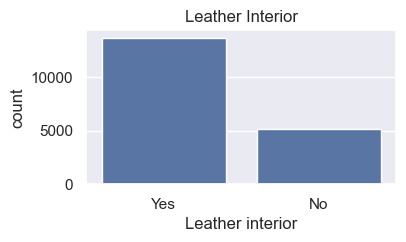

In [20]:
plt.figure(figsize=(4,2))
sns.countplot(data=df, x="Leather interior")
plt.title("Leather Interior")
plt.show()

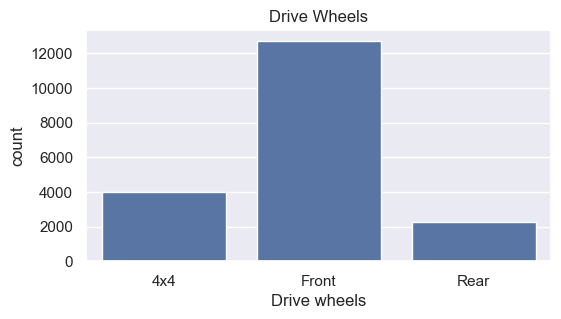

In [21]:
plt.figure(figsize=(6,3))
sns.countplot(data=df, x="Drive wheels")
plt.title("Drive Wheels")
plt.show()

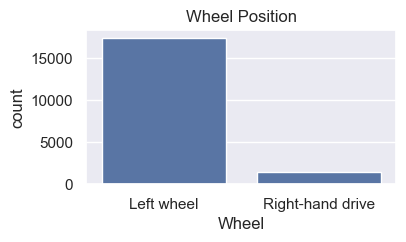

In [22]:
plt.figure(figsize=(4,2))
sns.countplot(data=df, x="Wheel")
plt.title("Wheel Position")
plt.show()

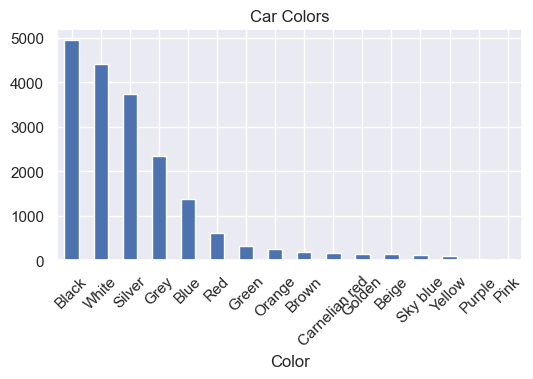

In [23]:
plt.figure(figsize=(6,3))
df["Color"].value_counts().plot(kind="bar")
plt.title("Car Colors")
plt.xticks(rotation=45)
plt.show()

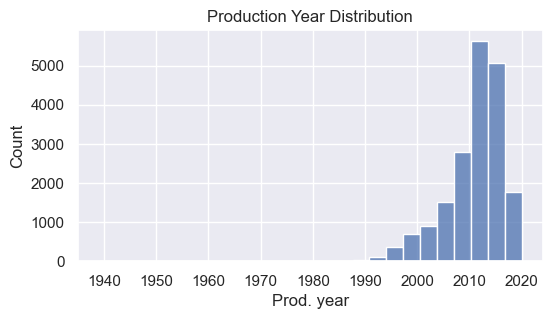

In [24]:
plt.figure(figsize=(6,3))
sns.histplot(df["Prod. year"], bins=25)
plt.title("Production Year Distribution")
plt.show()

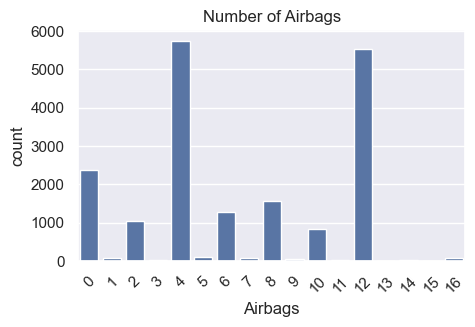

In [25]:
plt.figure(figsize=(5,3))
sns.countplot(data=df, x="Airbags")
plt.title("Number of Airbags")
plt.xticks(rotation=45)
plt.show()

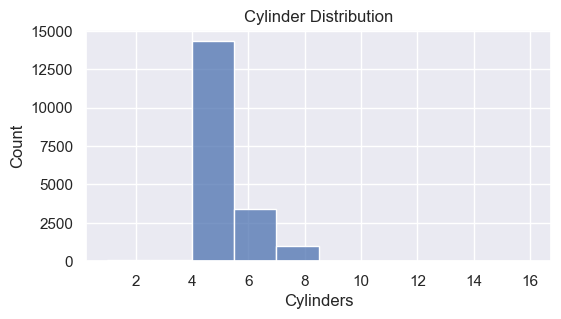

In [26]:
plt.figure(figsize=(6,3))
sns.histplot(df["Cylinders"], bins=10)
plt.title("Cylinder Distribution")
plt.show()

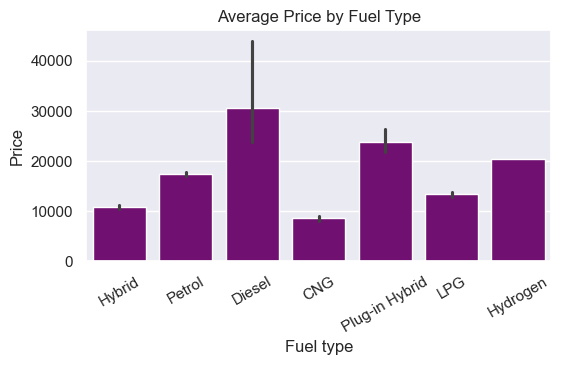

In [75]:
plt.figure(figsize=(6,3))
sns.barplot(data=df,
            x="Fuel type",
            y="Price",color = 'purple')
plt.title("Average Price by Fuel Type")
plt.xticks(rotation=30)
plt.show()

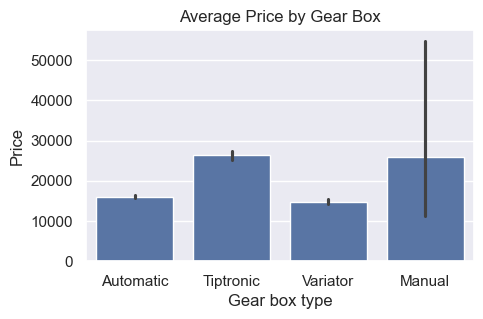

In [28]:
plt.figure(figsize=(5,3))
sns.barplot(data=df,
            x="Gear box type",
            y="Price")
plt.title("Average Price by Gear Box")
plt.show()

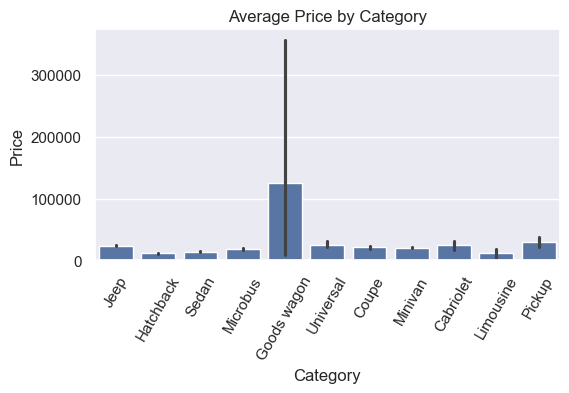

In [29]:
plt.figure(figsize=(6,3))
sns.barplot(
    data=df,
    x="Category",
    y="Price"
)
plt.xticks(rotation=60)
plt.title("Average Price by Category")
plt.show()

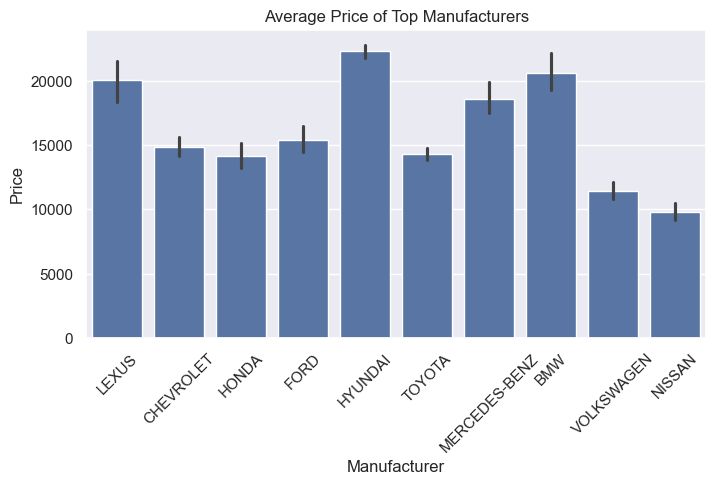

In [30]:
top10 = df["Manufacturer"].value_counts().head(10).index
plt.figure(figsize=(8,4))
sns.barplot(
    data=df[df["Manufacturer"].isin(top10)],
    x="Manufacturer",
    y="Price"
)
plt.xticks(rotation=45)
plt.title("Average Price of Top Manufacturers")
plt.show()

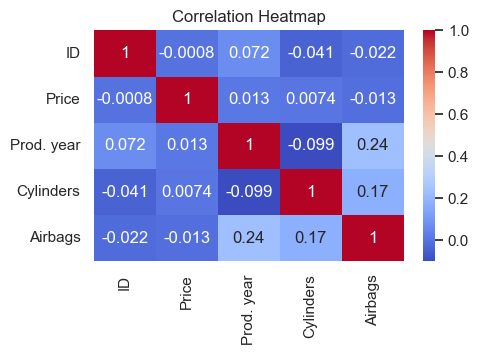

In [31]:
plt.figure(figsize=(5,3))
numeric_df = df.select_dtypes(include=["int64","float64"])
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()

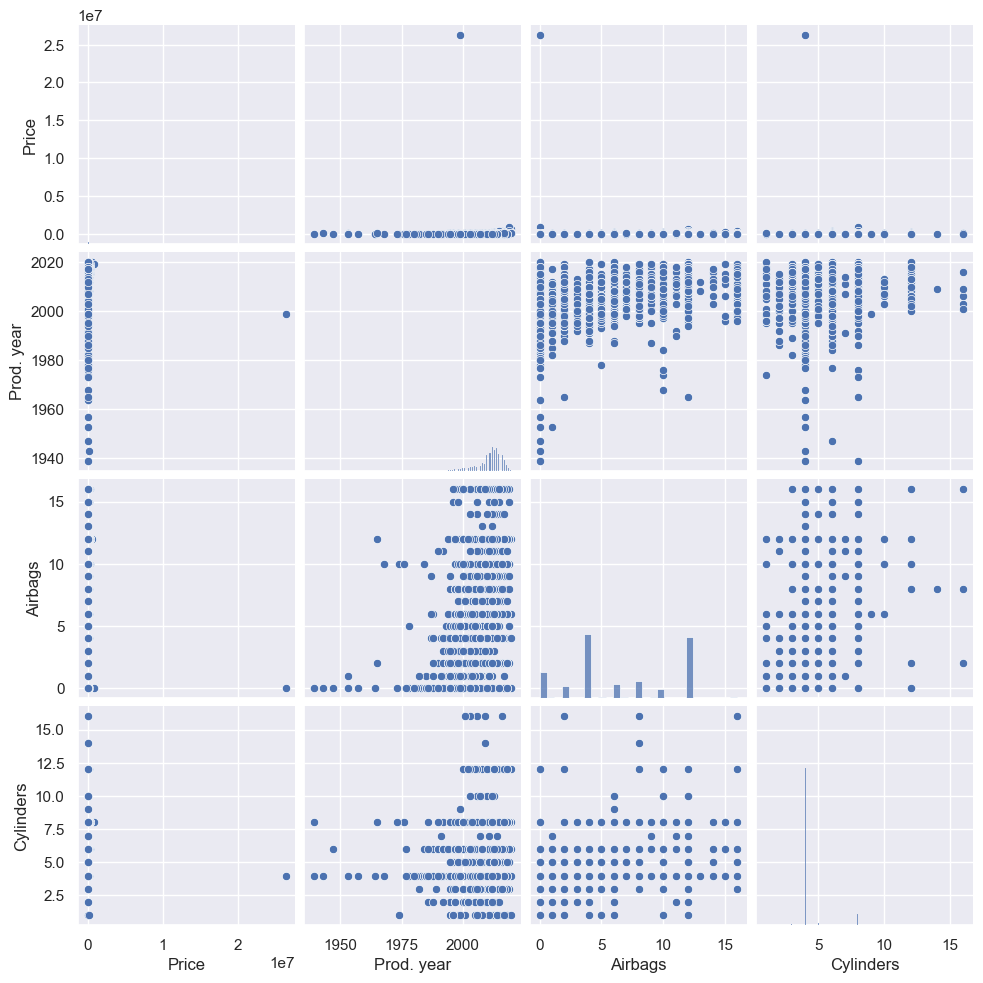

In [32]:
sns.pairplot(
    df[["Price","Prod. year","Airbags","Cylinders"]]
)
plt.show()

### 🤖 Part 3 — Data Preprocessing + Feature Engineering + Model Training

In [33]:
car_df = df.copy()
car_df.head()

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4


In [34]:
car_df.drop("ID", axis=1, inplace=True)
car_df.head()

,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4


In [35]:
car_df["Levy"] = car_df["Levy"].replace("-", np.nan)
car_df["Levy"] = pd.to_numeric(car_df["Levy"])
car_df["Levy"].fillna(car_df["Levy"].median(), inplace=True)

0        1399.0
1        1018.0
2         781.0
3         862.0
4         446.0
          ...  
19232     781.0
19233     831.0
19234     836.0
19235    1288.0
19236     753.0
Name: Levy, Length: 18924, dtype: float64

In [36]:
car_df["Mileage"] = car_df["Mileage"].str.replace(" km", "")
car_df["Mileage"] = car_df["Mileage"].str.replace(",", "")
car_df["Mileage"] = car_df["Mileage"].astype(int)

In [37]:
car_df["Engine volume"] = car_df["Engine volume"].str.extract(r'(\d+\.\d+)')
car_df["Engine volume"] = car_df["Engine volume"].astype(float)

In [38]:
car_df.info()
car_df.isnull().sum()
car_df.fillna(car_df.median(numeric_only=True), inplace=True)

<class 'pandas.DataFrame'>
Index: 18924 entries, 0 to 19236
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Price             18924 non-null  int64  
 1   Levy              13215 non-null  float64
 2   Manufacturer      18924 non-null  str    
 3   Model             18924 non-null  str    
 4   Prod. year        18924 non-null  int64  
 5   Category          18924 non-null  str    
 6   Leather interior  18924 non-null  str    
 7   Fuel type         18924 non-null  str    
 8   Engine volume     13947 non-null  float64
 9   Mileage           18924 non-null  int64  
 10  Cylinders         18924 non-null  float64
 11  Gear box type     18924 non-null  str    
 12  Drive wheels      18924 non-null  str    
 13  Doors             18924 non-null  str    
 14  Wheel             18924 non-null  str    
 15  Color             18924 non-null  str    
 16  Airbags           18924 non-null  int64  
dtypes: float6

,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,13328,1399.0,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,16621,1018.0,CHEVROLET,Equinox,2011,Jeep,No,Petrol,2.2,192000,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,8467,781.0,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,3607,862.0,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,11726,446.0,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901,4.0,Automatic,Front,04-May,Left wheel,Silver,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19232,8467,781.0,MERCEDES-BENZ,CLK 200,1999,Coupe,Yes,CNG,2.0,300000,4.0,Manual,Rear,02-Mar,Left wheel,Silver,5
19233,15681,831.0,HYUNDAI,Sonata,2011,Sedan,Yes,Petrol,2.4,161600,4.0,Tiptronic,Front,04-May,Left wheel,Red,8
19234,26108,836.0,HYUNDAI,Tucson,2010,Jeep,Yes,Diesel,2.2,116365,4.0,Automatic,Front,04-May,Left wheel,Grey,4
19235,5331,1288.0,CHEVROLET,Captiva,2007,Jeep,Yes,Diesel,2.2,51258,4.0,Automatic,Front,04-May,Left wheel,Black,4


In [39]:
X = car_df.drop("Price", axis=1)
y = car_df["Price"]
X.head()

,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,1399.0,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,1018.0,CHEVROLET,Equinox,2011,Jeep,No,Petrol,2.2,192000,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,781.0,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,862.0,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,446.0,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901,4.0,Automatic,Front,04-May,Left wheel,Silver,4


In [40]:
X = pd.get_dummies(X, drop_first=True)
X.head()
print(X.shape)

(18924, 1699)


In [41]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [42]:
# feature scaling:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [43]:
# import models:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [47]:
linear_model = LinearRegression()

linear_model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [44]:
# train decicion tree:
tree_model = DecisionTreeRegressor(
    random_state=42
)
tree_model.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_l

In [45]:
forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
forest_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [48]:
linear_pred = linear_model.predict(X_test_scaled)
tree_pred = tree_model.predict(X_test)
forest_pred = forest_model.predict(X_test)

In [49]:
prediction_df = pd.DataFrame({
    "Actual Price": y_test.values,
    "Linear Prediction": linear_pred,
    "Decision Tree": tree_pred,
    "Random Forest": forest_pred
})
prediction_df.head(10)

,Actual Price,Linear Prediction,Decision Tree,Random Forest
0,11604,11691.974534,18000.0,14003.640
1,470,8588.529262,549.0,782.610
2,20162,16752.936043,20165.0,30607.550
3,7527,-1913.685388,6899.0,6823.520
4,18817,12904.295140,11290.0,11052.550
5,44003,45105.289229,45633.0,42683.880
6,21326,13914.514381,16308.0,12906.820
7,15681,27364.137755,14000.0,15459.285
8,6899,-7692.266205,15994.0,6169.860
9,1333,7423.949197,1333.0,1376.090


### 🚀 Part 4 — Model Evaluation + Visualization + Prediction

In [50]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

In [51]:
linear_mae = mean_absolute_error(y_test, linear_pred)
linear_mse = mean_squared_error(y_test, linear_pred)
linear_rmse = np.sqrt(linear_mse)
linear_r2 = r2_score(y_test, linear_pred)

In [52]:
tree_mae = mean_absolute_error(y_test, tree_pred)
tree_mse = mean_squared_error(y_test, tree_pred)
tree_rmse = np.sqrt(tree_mse)
tree_r2 = r2_score(y_test, tree_pred)

In [53]:
forest_mae = mean_absolute_error(y_test, forest_pred)
forest_mse = mean_squared_error(y_test, forest_pred)
forest_rmse = np.sqrt(forest_mse)
forest_r2 = r2_score(y_test, forest_pred)

In [54]:
results = pd.DataFrame({
    "Model":[
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE":[
        linear_mae,
        tree_mae,
        forest_mae
    ],
    "MSE":[
        linear_mse,
        tree_mse,
        forest_mse
    ],
    "RMSE":[
        linear_rmse,
        tree_rmse,
        forest_rmse
    ],
    "R2 Score":[
        linear_r2,
        tree_r2,
        forest_r2
    ]
})
results

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,14276.270707,1.367007e+09,36973.055370,-2.948283
1,Decision Tree,12289.554253,1.829178e+11,427688.916902,-527.315734
2,Random Forest,7915.691748,4.579838e+10,214005.556886,-131.278010


In [55]:
results.sort_values(
    by="R2 Score",
    ascending=False
)

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,14276.270707,1.367007e+09,36973.055370,-2.948283
2,Random Forest,7915.691748,4.579838e+10,214005.556886,-131.278010
1,Decision Tree,12289.554253,1.829178e+11,427688.916902,-527.315734


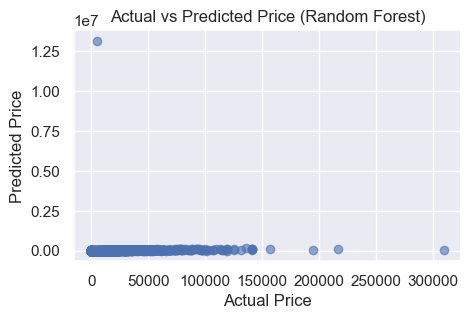

In [56]:
plt.figure(figsize=(5,3))
plt.scatter(
    y_test,
    forest_pred,
    alpha=0.6
)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price (Random Forest)")
plt.show()

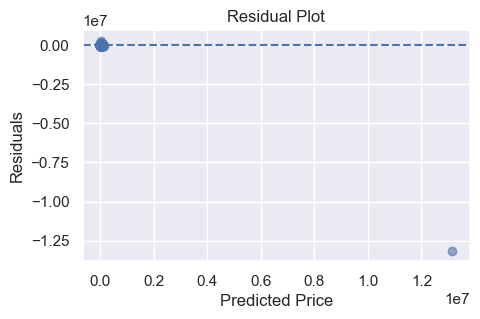

In [57]:
# resudual plot:
residuals = y_test - forest_pred
plt.figure(figsize=(5,3))
plt.scatter(
    forest_pred,
    residuals,
    alpha=0.6
)
plt.axhline(
    y=0,
    linestyle="--"
)
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [58]:
importance = pd.DataFrame({
    "Feature":X.columns,
    "Importance":forest_model.feature_importances_
})
importance = importance.sort_values(
    by="Importance",
    ascending=False
)
importance.head(15)

,Feature,Importance
1,Prod. year,0.554057
5,Airbags,0.069820
2,Engine volume,0.041232
831,Model_G 65 AMG 63AMG,0.028769
560,Model_Combo,0.028678
1677,Gear box type_Tiptronic,0.028437
3,Mileage,0.028147
34,Manufacturer_LAMBORGHINI,0.024701
1670,Fuel type_Diesel,0.020964
1519,Model_Urus,0.020203


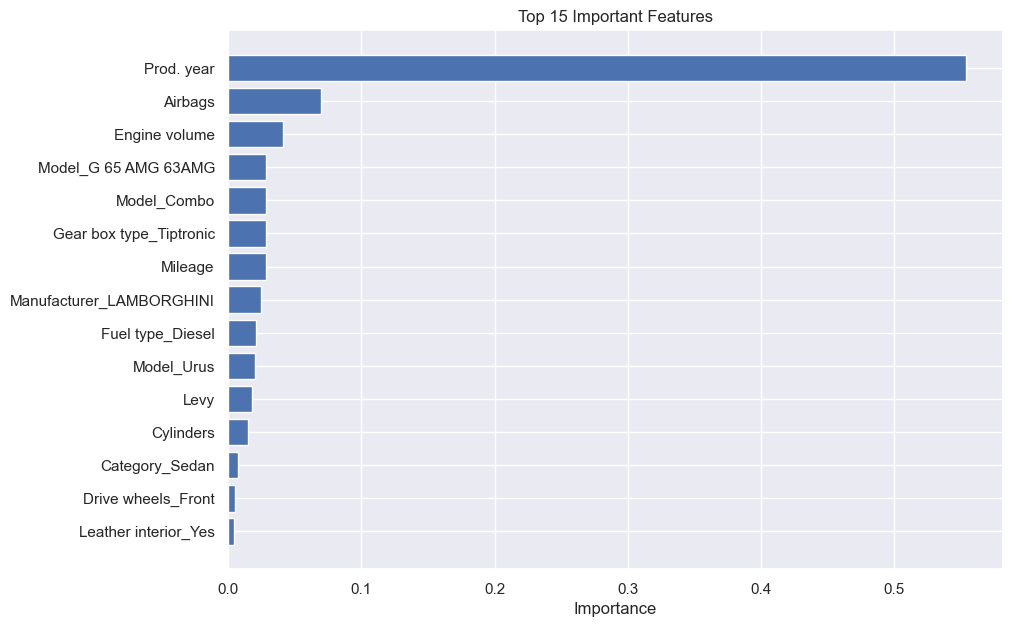

In [59]:
plt.figure(figsize=(10,7))
plt.barh(
    importance["Feature"].head(15),
    importance["Importance"].head(15)
)
plt.gca().invert_yaxis()
plt.title("Top 15 Important Features")
plt.xlabel("Importance")
plt.show()

In [60]:
sample_car = X.iloc[[0]]
predicted_price = forest_model.predict(sample_car)
print("Predicted Price:", predicted_price[0])

Predicted Price: 13409.328710249012


In [61]:
import joblib
joblib.dump(
    forest_model,
    "car_price_prediction_model.pkl"
)

['car_price_prediction_model.pkl']

In [62]:
joblib.dump(
    scaler,
    "scaler.pkl"
)

['scaler.pkl']

In [63]:
loaded_model = joblib.load(
    "car_price_prediction_model.pkl"
)

In [64]:
loaded_model.predict(sample_car)

array([13409.32871025])

In [65]:
import joblib

joblib.dump(X.columns.tolist(), "feature_columns.pkl")

['feature_columns.pkl']

In [70]:
import joblib

joblib.dump(forest_model, "model/car_price_prediction_model.pkl")

['model/car_price_prediction_model.pkl']

In [71]:
joblib.dump(scaler, "model/scaler.pkl")

['model/scaler.pkl']

In [72]:
joblib.dump(
    X.columns.tolist(),
    "model/feature_columns.pkl"
)

['model/feature_columns.pkl']

In [73]:
categories = {

    "Manufacturer": sorted(df["Manufacturer"].unique()),

    "Category": sorted(df["Category"].unique()),

    "Fuel type": sorted(df["Fuel type"].unique()),

    "Gear box type": sorted(df["Gear box type"].unique()),

    "Drive wheels": sorted(df["Drive wheels"].unique()),

    "Leather interior": sorted(df["Leather interior"].unique()),

    "Wheel": sorted(df["Wheel"].unique()),

    "Doors": sorted(df["Doors"].unique()),

    "Color": sorted(df["Color"].unique()),

    "Model": sorted(df["Model"].unique())

}

joblib.dump(
    categories,
    "model/categories.pkl"
)

['model/categories.pkl']

# Conclusion

In this project, we developed a machine learning model to predict car prices using various vehicle features such as manufacturer, production year, mileage, engine volume, fuel type, gearbox type, airbags, and more.

The project followed a complete machine learning pipeline:

- Data Loading
- Data Cleaning
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Data Preprocessing
- Model Training
- Model Evaluation
- Feature Importance Analysis
- Model Saving

Three regression algorithms were trained:

- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor

Among them, the Random Forest model achieved the best performance and was selected as the final prediction model.

This project demonstrates how machine learning can support real-world car price estimation and provides a strong foundation for deployment as a web application using Flask or Streamlit.